In [8]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

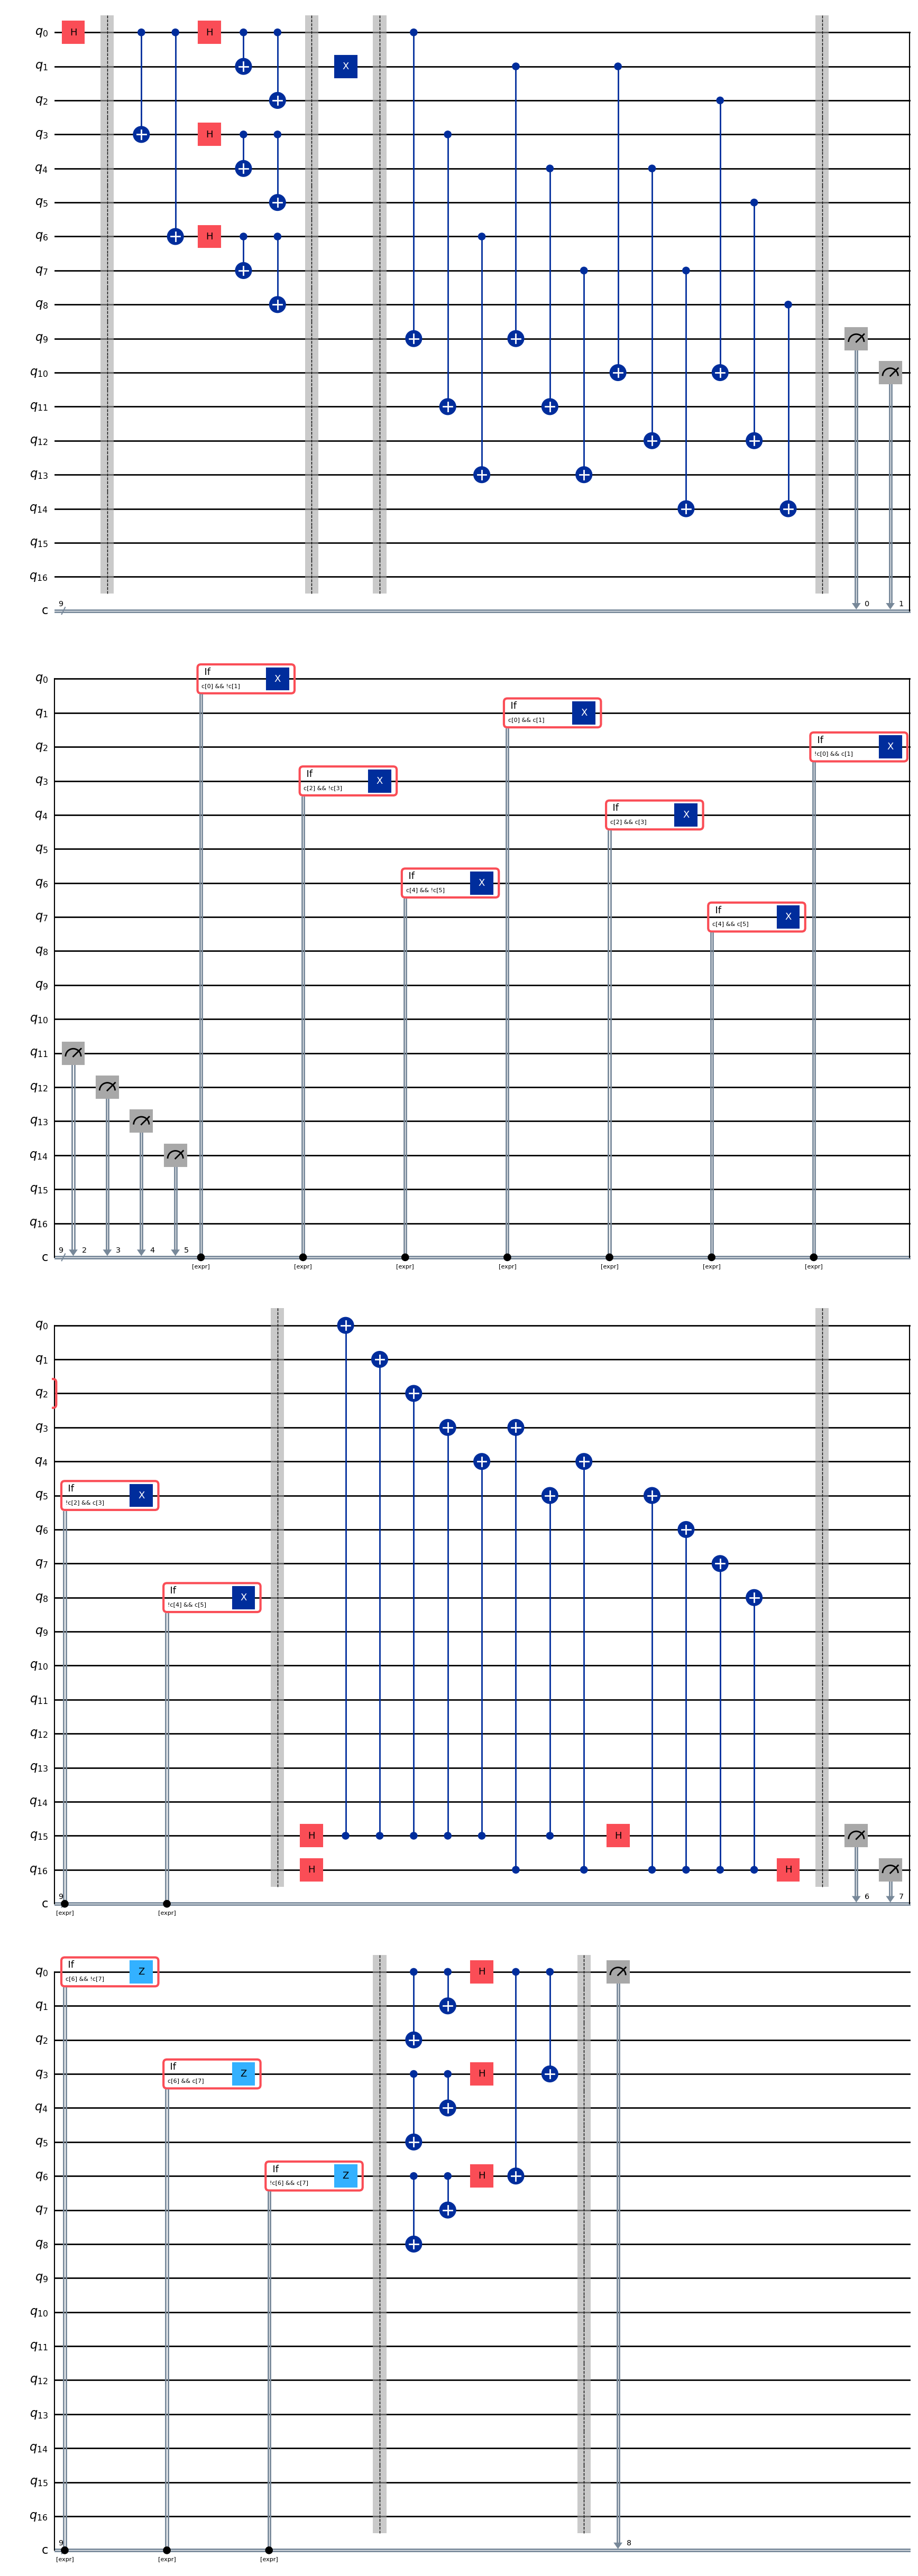

In [9]:
from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.visualization import plot_histogram
from qiskit.result import marginal_counts
from qiskit.circuit import ControlledGate
from qiskit.circuit.classical import expr
import math

# Shor code

# Implement the Shor code and experiment with it, checking that it can correct bit-flip and phase-flip errors.
# You can also try applying some other unitary operator as an error, e.g. H.
# You can even construct a unitary operator from a function (as in Lab 3) and apply it as an error.
# You need more qubits now, so you will also have to change the simulation and measurement code in the next cell.

flip = QuantumCircuit(17, 9)

flip.h(0)   # put q0 into |+> = (|0>+|1>)/sqrt(2)

flip.barrier()

# ===== ENCODING =====
# Outer phase-flip repetition code: spread logical qubit to all three groups
flip.cx(0, 3)
flip.cx(0, 6)
# Hadamard on group leaders encodes into the phase (Hadamard) basis:
#   |0> -> |+>  and  |1> -> |->
flip.h(0)
flip.h(3)
flip.h(6)
# Inner bit-flip repetition code: spread each group leader to its two copies
flip.cx(0, 1)
flip.cx(0, 2)
flip.cx(3, 4)
flip.cx(3, 5)
flip.cx(6, 7)
flip.cx(6, 8)

flip.barrier()

# ===== ERROR INJECTION =====
# Uncomment one line at a time to test different errors.
# The Shor code corrects any single-qubit error on any of q0-q8.
flip.x(1)        # bit-flip error on qubit 1  (within group 1)
# flip.z(0)      # phase-flip error on qubit 0 (group 1 leader)
# flip.z(3)      # phase-flip error on qubit 3 (group 2 leader)

flip.barrier()

# ===== BIT-FLIP SYNDROME MEASUREMENT =====
# Same CNOT pattern as Lab4-A, applied independently to each group.
# Group 1 (q0,q1,q2 -> ancilla q9,q10)
flip.cx(0, 9)
flip.cx(1, 9)
flip.cx(1, 10)
flip.cx(2, 10)
# Group 2 (q3,q4,q5 -> ancilla q11,q12)
flip.cx(3, 11)
flip.cx(4, 11)
flip.cx(4, 12)
flip.cx(5, 12)
# Group 3 (q6,q7,q8 -> ancilla q13,q14)
flip.cx(6, 13)
flip.cx(7, 13)
flip.cx(7, 14)
flip.cx(8, 14)

flip.barrier()
flip.measure([9, 10],  [0, 1])
flip.measure([11, 12], [2, 3])
flip.measure([13, 14], [4, 5])

# ===== BIT-FLIP CORRECTIONS =====
# Same logic as Lab4-A, applied independently to each group.
# Group 1
with flip.if_test(expr.logic_and(flip.clbits[0], expr.logic_not(flip.clbits[1]))):
    flip.x(0)
with flip.if_test(expr.logic_and(flip.clbits[0], flip.clbits[1])):
    flip.x(1)
with flip.if_test(expr.logic_and(expr.logic_not(flip.clbits[0]), flip.clbits[1])):
    flip.x(2)

# Group 2
with flip.if_test(expr.logic_and(flip.clbits[2], expr.logic_not(flip.clbits[3]))):
    flip.x(3)
with flip.if_test(expr.logic_and(flip.clbits[2], flip.clbits[3])):
    flip.x(4)
with flip.if_test(expr.logic_and(expr.logic_not(flip.clbits[2]), flip.clbits[3])):
    flip.x(5)

# Group 3
with flip.if_test(expr.logic_and(flip.clbits[4], expr.logic_not(flip.clbits[5]))):
    flip.x(6)
with flip.if_test(expr.logic_and(flip.clbits[4], flip.clbits[5])):
    flip.x(7)
with flip.if_test(expr.logic_and(expr.logic_not(flip.clbits[4]), flip.clbits[5])):
    flip.x(8)

flip.barrier()

# ===== PHASE-FLIP SYNDROME MEASUREMENT =====
# Each ancilla measures the X-stabilizer parity across two adjacent groups.
# Prepare ancilla in |+>, apply CX (ancilla controls each data qubit), apply H, measure.
# If groups have the same phase sign -> ancilla measures 0.
# If groups have different phase signs -> ancilla measures 1.

# Ancilla q15: parity between group 1 and group 2
flip.h(15)
flip.cx(15, 0)
flip.cx(15, 1)
flip.cx(15, 2)
flip.cx(15, 3)
flip.cx(15, 4)
flip.cx(15, 5)
flip.h(15)

# Ancilla q16: parity between group 2 and group 3
flip.h(16)
flip.cx(16, 3)
flip.cx(16, 4)
flip.cx(16, 5)
flip.cx(16, 6)
flip.cx(16, 7)
flip.cx(16, 8)
flip.h(16)

flip.barrier()
flip.measure([15, 16], [6, 7])

# ===== PHASE-FLIP CORRECTIONS =====
# Apply Z to the group leader of the affected group.
# Z applied to the group leader flips the sign of that group's codeword.
# Syndrome (cl6, cl7):
#   (1, 0) -> group 1 has wrong sign -> Z(q0)
#   (1, 1) -> group 2 has wrong sign -> Z(q3)
#   (0, 1) -> group 3 has wrong sign -> Z(q6)
with flip.if_test(expr.logic_and(flip.clbits[6], expr.logic_not(flip.clbits[7]))):
    flip.z(0)
with flip.if_test(expr.logic_and(flip.clbits[6], flip.clbits[7])):
    flip.z(3)
with flip.if_test(expr.logic_and(expr.logic_not(flip.clbits[6]), flip.clbits[7])):
    flip.z(6)

flip.barrier()

# ===== DECODING =====
# Reverse the encoding gates in the opposite order.
# Undo inner bit-flip encoding for each group
flip.cx(6, 8)
flip.cx(6, 7)
flip.cx(3, 5)
flip.cx(3, 4)
flip.cx(0, 2)
flip.cx(0, 1)
# Undo Hadamard on group leaders
flip.h(6)
flip.h(3)
flip.h(0)
# Undo outer CNOT spreading
flip.cx(0, 6)
flip.cx(0, 3)

flip.barrier()

# Measure the decoded logical qubit (q0).
# If the Shor code worked, q0 is back to its original state |+> = (|0>+|1>)/sqrt(2),
# so the histogram should show ~50% '0' and ~50% '1'.
flip.measure([0], [8])

flip.draw("mpl")

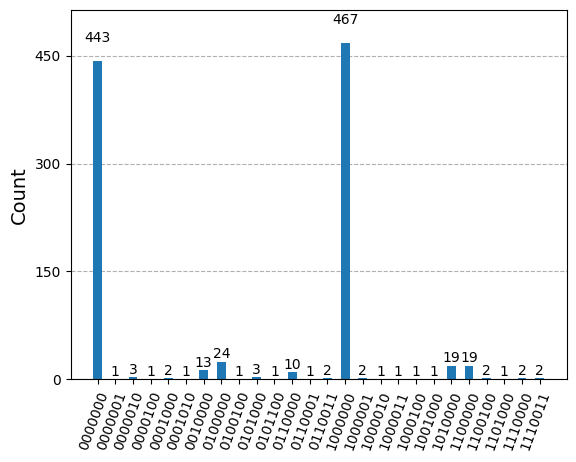

In [10]:
# Simulate and plot results

backend = GenericBackendV2(num_qubits=17, control_flow=True)
compiled = transpile(flip, backend)
job_sim = backend.run(compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(compiled)
# We only want to see the results for bits 2, 3, 4
# mcounts = marginal_counts(counts,indices=[2,3,4])
mcounts = marginal_counts(counts,indices=[2,3,4,5,6,7,8])
plot_histogram(mcounts)